# Water-quality clustering with sensor-specific feature sets

This notebook performs K-means clustering separately for each sensor.

Sensors **977** and **981** use only:

- conductivity;
- ORP;
- turbidity.

Oxygen saturation is retained in the dataframe for inspection, but it is excluded from both clustering and quality-score calculation for those two sensors because its historical trend is suspected to reflect probe drift.

All other sensors use the four measurements, including oxygen saturation.


In [1]:
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# The dashboard/inspection helpers are optional.
# The clustering pipeline can run even if funcs.py is temporarily unavailable.
try:
    import funcs
    importlib.reload(funcs)

    from funcs import (
        inspect_sensors,
        build_latest_sensor_statuses,
    )
except (ImportError, AttributeError) as error:
    inspect_sensors = None
    build_latest_sensor_statuses = None
    print(f"Optional funcs.py helpers were not loaded: {error}")


## 1. Load the cleaned data

When `df_model` already exists in the notebook session, it is used directly. Otherwise, the notebook reads the configured CSV file.


In [20]:
DATA_PATH = r"C:\Users\User\Desktop\water\data\cleaned_stats.csv"
df_model = pd.read_csv(r'C:\Users\User\Desktop\water\data\water_model_ready.csv')
if "df_model" in globals() and isinstance(df_model, pd.DataFrame):
    df = df_model.copy()
    print("Using the existing dataframe: df_model")
elif "df" in globals() and isinstance(df, pd.DataFrame):
    df = df.copy()
    print("Using the existing dataframe: df")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded: {DATA_PATH}")

print(f"Rows loaded: {len(df):,}")
display(df.head())


Using the existing dataframe: df_model
Rows loaded: 21,161


,date_insert,sensor_id,id,year,month,day,hour,lat,lng,wtempV_°C,...,turbidity_NTU__statistical_suspect,any_statistical_suspect,oxygen_mean_24h,oxygen_std_24h,oxygen_mean_7d,oxygen_7d_change_vs_3d_ago,oxygen_low_24h_flag,oxygen_noisy_24h_flag,oxygen_downward_drift_flag,oxygen_sensor_suspect
0,2025-07-03 15:00:00,976,3.0,2025.0,7.0,3.0,15.0,38.310409,21.784038,24.96,...,False,False,NaN,NaN,NaN,NaN,False,False,False,False
1,2025-07-03 16:00:00,976,12.0,2025.0,7.0,3.0,16.0,38.310409,21.784038,25.16,...,False,False,NaN,NaN,NaN,NaN,False,False,False,False
2,2025-07-03 17:00:00,976,21.0,2025.0,7.0,3.0,17.0,38.310409,21.784038,24.70,...,False,False,NaN,NaN,NaN,NaN,False,False,False,False
3,2025-07-03 18:00:00,976,30.0,2025.0,7.0,3.0,18.0,38.310409,21.784038,24.63,...,False,False,NaN,NaN,NaN,NaN,False,False,False,False
4,2025-07-03 21:00:00,976,57.0,2025.0,7.0,3.0,21.0,38.310409,21.784038,24.55,...,False,False,95.03375,1.294096,NaN,NaN,False,False,False,False


## 2. Configuration

The scoring formula is converted to a weighted average. This keeps three-feature scores for sensors 977 and 981 more comparable with the four-feature scores used for the other sensors.


In [3]:
sensor_id_col = "sensor_id"
timestamp_col = "date_insert"

conductivity_col = "conductivity_of_solution_ mS_cm"
orp_col = "oxidation_reduction_potential_ mV"
oxygen_col = "oxygen_saturation_%"
turbidity_col = "turbidity_NTU"

all_features = [
    conductivity_col,
    orp_col,
    oxygen_col,
    turbidity_col,
]

three_feature_set = [
    conductivity_col,
    orp_col,
    turbidity_col,
]

N_CLUSTERS = 3
RANDOM_STATE = 42

# Oxygen is considered unreliable for these sensors.
OXYGEN_EXCLUDED_SENSORS = {977, 981}

# Weights used when K-means creates the clusters.
clustering_weights = {
    conductivity_col: 1.0,
    orp_col: 2.0,
    oxygen_col: 0.8,
    turbidity_col: 2.0,
}

# Weights used when interpreting and labelling the clusters.
label_weights = {
    "conductivity_deviation": 1.0,
    "orp": 2.0,
    "oxygen": 0.8,
    "turbidity": 2.0,
}


def features_for_sensor(sensor_id):
    """Return the trusted clustering features for one sensor."""
    if sensor_id in OXYGEN_EXCLUDED_SENSORS:
        return three_feature_set.copy()

    return all_features.copy()


## 3. Validate columns and retain usable rows

Rows from sensors 977 and 981 are allowed to have missing oxygen values because oxygen is not used for those sensors. Other sensors still require all four measurements.


In [4]:
required_columns = [
    sensor_id_col,
    conductivity_col,
    orp_col,
    oxygen_col,
    turbidity_col,
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"The following required columns are missing: {missing_columns}"
    )

input_df = df.copy().reset_index(drop=True)
input_df["_source_row_id"] = np.arange(len(input_df))

usable_parts = []
row_audit = []

for sensor, sensor_df in input_df.groupby(
    sensor_id_col,
    sort=False,
):
    active_features = features_for_sensor(sensor)

    usable_mask = sensor_df[active_features].notna().all(axis=1)
    usable_sensor_df = sensor_df.loc[usable_mask].copy()

    usable_parts.append(usable_sensor_df)

    row_audit.append({
        sensor_id_col: sensor,
        "features_used": ", ".join(active_features),
        "input_rows": len(sensor_df),
        "usable_rows": int(usable_mask.sum()),
        "excluded_rows": int((~usable_mask).sum()),
        "oxygen_used_in_model": sensor not in OXYGEN_EXCLUDED_SENSORS,
    })

if not usable_parts:
    raise ValueError("No rows were usable for clustering.")

work_df = (
    pd.concat(usable_parts, axis=0)
    .sort_values("_source_row_id")
    .reset_index(drop=True)
)

# Use a fresh, contiguous row ID for alignment inside this notebook.
work_df["_row_id"] = np.arange(len(work_df))

row_audit_df = pd.DataFrame(row_audit)

print(f"Rows available for clustering: {len(work_df):,}")
print(f"Sensors available: {work_df[sensor_id_col].nunique()}")
display(row_audit_df)


Rows available for clustering: 21,161
Sensors available: 9


,sensor_id,features_used,input_rows,usable_rows,excluded_rows,oxygen_used_in_model
0,976,"conductivity_of_solution_ mS_cm, oxidation_red...",1257,1257,0,True
1,977,"conductivity_of_solution_ mS_cm, oxidation_red...",2208,2208,0,False
2,978,"conductivity_of_solution_ mS_cm, oxidation_red...",1749,1749,0,True
3,979,"conductivity_of_solution_ mS_cm, oxidation_red...",3490,3490,0,True
4,980,"conductivity_of_solution_ mS_cm, oxidation_red...",2227,2227,0,True
5,981,"conductivity_of_solution_ mS_cm, oxidation_red...",1631,1631,0,False
6,982,"conductivity_of_solution_ mS_cm, oxidation_red...",3157,3157,0,True
7,983,"conductivity_of_solution_ mS_cm, oxidation_red...",2523,2523,0,True
8,984,"conductivity_of_solution_ mS_cm, oxidation_red...",2919,2919,0,True


## 4. Robust scaling and clustering weights

A separate `RobustScaler` is fitted for every measurement. The oxygen scaler is fitted only on sensors whose oxygen channel is trusted, so the suspected drift in sensors 977 and 981 does not influence scaling for other sensors.


In [5]:
feature_scalers = {}
scaled_feature_df = pd.DataFrame(
    index=work_df.index,
    columns=all_features,
    dtype=float,
)

for feature in all_features:
    fit_mask = work_df[feature].notna()

    if feature == oxygen_col:
        fit_mask &= ~work_df[sensor_id_col].isin(
            OXYGEN_EXCLUDED_SENSORS
        )

    if fit_mask.sum() == 0:
        raise ValueError(
            f"No trusted non-missing values were available for {feature}."
        )

    scaler = RobustScaler()
    scaler.fit(work_df.loc[fit_mask, [feature]])
    feature_scalers[feature] = scaler

    transform_mask = work_df[feature].notna()

    scaled_feature_df.loc[transform_mask, feature] = (
        scaler.transform(
            work_df.loc[transform_mask, [feature]]
        ).ravel()
    )

# Weighted feature space used by K-means.
df_scaled = scaled_feature_df.copy()

for feature, weight in clustering_weights.items():
    df_scaled[feature] = df_scaled[feature] * weight

display(df_scaled.head())


,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU
0,0.098698,-2.184916,0.725418,-0.617339
1,-0.178213,-2.188847,0.718698,0.641423
2,0.076386,-2.181574,0.730938,0.043504
3,0.110442,-2.184261,0.740539,0.301465
4,0.122680,-2.229605,0.645976,-0.846622


## 5. Fit one K-means model per sensor

Sensors 977 and 981 are clustered in a three-dimensional feature space. The remaining sensors are clustered in a four-dimensional feature space.


In [6]:
processed_sensor_dfs = []
skipped_sensors = []

sensor_kmeans_models = {}
sensor_feature_sets = {}

for sensor, sensor_indices in work_df.groupby(
    sensor_id_col,
    sort=False,
).groups.items():

    sensor_indices = pd.Index(sensor_indices)
    active_features = features_for_sensor(sensor)

    sensor_data = df_scaled.loc[
        sensor_indices,
        active_features,
    ]

    original_sensor_data = work_df.loc[
        sensor_indices
    ].copy()

    if len(sensor_data) < N_CLUSTERS:
        skipped_sensors.append({
            sensor_id_col: sensor,
            "reason": "Fewer rows than clusters",
        })
        continue

    if sensor_data.drop_duplicates().shape[0] < N_CLUSTERS:
        skipped_sensors.append({
            sensor_id_col: sensor,
            "reason": "Fewer distinct points than clusters",
        })
        continue

    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=20,
    )

    original_sensor_data["cluster"] = (
        kmeans.fit_predict(sensor_data)
    )

    original_sensor_data["oxygen_used_in_model"] = (
        sensor not in OXYGEN_EXCLUDED_SENSORS
    )

    original_sensor_data["model_features"] = ", ".join(
        active_features
    )

    sensor_kmeans_models[sensor] = kmeans
    sensor_feature_sets[sensor] = active_features

    processed_sensor_dfs.append(original_sensor_data)

if not processed_sensor_dfs:
    raise ValueError(
        "No sensor contained enough data to form three clusters."
    )

clustered_df = (
    pd.concat(processed_sensor_dfs, axis=0)
    .sort_values("_row_id")
)

print(f"Clustered rows: {len(clustered_df):,}")
print(f"Clustered sensors: {clustered_df[sensor_id_col].nunique()}")

if skipped_sensors:
    print("\nSkipped sensors:")
    display(pd.DataFrame(skipped_sensors))


Clustered rows: 21,161
Clustered sensors: 9


## 6. Calculate measurement-level quality scores

Positive contributions increase concern:

- higher turbidity;
- lower ORP;
- lower oxygen saturation, when oxygen is trusted;
- conductivity farther from the sensor’s usual range.

For sensors 977 and 981, oxygen contribution is exactly zero. The total is divided by the sum of the active weights so that three-feature and four-feature scores remain on a comparable scale.


In [7]:
label_scaled_df = pd.DataFrame(
    index=work_df.index,
)

label_scaled_df["scaled_turbidity"] = (
    scaled_feature_df[turbidity_col]
)

label_scaled_df["scaled_orp"] = (
    scaled_feature_df[orp_col]
)

label_scaled_df["scaled_oxygen"] = (
    scaled_feature_df[oxygen_col]
)


# Conductivity is interpreted as deviation from each sensor's normal range.
conductivity_group = work_df.groupby(
    sensor_id_col
)[conductivity_col]

conductivity_median = conductivity_group.transform("median")

conductivity_q1 = conductivity_group.transform(
    lambda values: values.quantile(0.25)
)

conductivity_q3 = conductivity_group.transform(
    lambda values: values.quantile(0.75)
)

conductivity_iqr = (
    conductivity_q3 - conductivity_q1
).replace(0, np.nan)

label_scaled_df["conductivity_deviation"] = (
    (
        work_df[conductivity_col] - conductivity_median
    ).abs()
    / conductivity_iqr
).fillna(0).clip(lower=0, upper=5)


label_scaled_df["turbidity_contribution"] = (
    label_weights["turbidity"]
    * label_scaled_df["scaled_turbidity"]
)

label_scaled_df["orp_contribution"] = (
    -label_weights["orp"]
    * label_scaled_df["scaled_orp"]
)

oxygen_is_active = ~work_df[sensor_id_col].isin(
    OXYGEN_EXCLUDED_SENSORS
)

label_scaled_df["oxygen_contribution"] = np.where(
    oxygen_is_active,
    -label_weights["oxygen"]
    * label_scaled_df["scaled_oxygen"],
    0.0,
)

label_scaled_df["conductivity_contribution"] = (
    label_weights["conductivity_deviation"]
    * label_scaled_df["conductivity_deviation"]
)

label_scaled_df["active_weight_sum"] = (
    label_weights["turbidity"]
    + label_weights["orp"]
    + label_weights["conductivity_deviation"]
    + np.where(
        oxygen_is_active,
        label_weights["oxygen"],
        0.0,
    )
)

contribution_columns = [
    "turbidity_contribution",
    "orp_contribution",
    "oxygen_contribution",
    "conductivity_contribution",
]

label_scaled_df["measurement_quality_score"] = (
    label_scaled_df[contribution_columns].sum(axis=1)
    / label_scaled_df["active_weight_sum"]
)

display(
    label_scaled_df[
        [
            "scaled_turbidity",
            "scaled_orp",
            "scaled_oxygen",
            "conductivity_deviation",
            *contribution_columns,
            "active_weight_sum",
            "measurement_quality_score",
        ]
    ].describe()
)


,scaled_turbidity,scaled_orp,scaled_oxygen,conductivity_deviation,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,active_weight_sum,measurement_quality_score
count,21161.000000,21161.000000,21161.000000,21161.000000,21161.000000,21161.000000,21161.000000,21161.000000,21161.000000,21161.000000
mean,0.164199,-0.087553,-0.225498,0.748325,0.328399,0.175107,0.037841,0.748325,5.654865,0.228310
std,0.697668,0.559179,0.954118,0.891287,1.395337,1.118358,0.661656,0.891287,0.308299,0.402609
min,-0.589670,-1.646845,-1.961899,0.000000,-1.179341,-1.416224,-3.150199,0.000000,5.000000,-0.485882
25%,-0.438103,-0.561169,-0.828771,0.220413,-0.876205,-0.877662,-0.330368,0.220413,5.800000,-0.093914
50%,0.000000,0.000000,-0.142954,0.434761,0.000000,0.000000,0.000000,0.434761,5.800000,0.192591
75%,0.561897,0.438831,0.435161,0.888893,1.123795,1.122338,0.240846,0.888893,5.800000,0.475892
max,2.887272,0.708112,3.937748,5.000000,5.774545,3.293690,1.569519,5.000000,5.800000,1.942156


In [8]:
clustered_df["measurement_quality_score"] = (
    label_scaled_df.loc[
        clustered_df["_row_id"],
        "measurement_quality_score",
    ].to_numpy()
)


## 7. Summarize and label clusters

The cluster label is based on the median quality score of the cluster. Global one-third and two-third cutoffs are applied to the weighted-average scores.


In [9]:
cluster_quality = (
    clustered_df
    .groupby(
        [sensor_id_col, "cluster"],
        as_index=False,
    )
    .agg(
        cluster_quality_score=(
            "measurement_quality_score",
            "median",
        ),
        mean_quality_score=(
            "measurement_quality_score",
            "mean",
        ),
        median_turbidity=(
            turbidity_col,
            "median",
        ),
        median_orp=(
            orp_col,
            "median",
        ),
        median_oxygen=(
            oxygen_col,
            "median",
        ),
        median_conductivity=(
            conductivity_col,
            "median",
        ),
        observations=(
            "cluster",
            "size",
        ),
        oxygen_used_in_model=(
            "oxygen_used_in_model",
            "first",
        ),
        model_features=(
            "model_features",
            "first",
        ),
    )
    .sort_values("cluster_quality_score")
    .reset_index(drop=True)
)

ok_cutoff = cluster_quality[
    "cluster_quality_score"
].quantile(1 / 3)

danger_cutoff = cluster_quality[
    "cluster_quality_score"
].quantile(2 / 3)

cluster_quality["Water_Quality_Label"] = np.select(
    [
        cluster_quality["cluster_quality_score"] <= ok_cutoff,
        cluster_quality["cluster_quality_score"] < danger_cutoff,
    ],
    [
        "Ok",
        "Medium",
    ],
    default="Danger",
)

print(f"Ok cutoff:     {ok_cutoff:.4f}")
print(f"Danger cutoff: {danger_cutoff:.4f}")

display(
    cluster_quality.sort_values(
        [sensor_id_col, "cluster_quality_score"]
    )
)


Ok cutoff:     0.1141
Danger cutoff: 0.4354


,sensor_id,cluster,cluster_quality_score,mean_quality_score,median_turbidity,median_orp,median_oxygen,median_conductivity,observations,oxygen_used_in_model,model_features,Water_Quality_Label
10,976,0,0.164910,0.194647,63.040,-127.910,91.080,56931.790,783,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium
18,976,1,0.444455,0.480447,196.475,-106.205,82.335,56988.010,450,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
24,976,2,0.771929,0.896874,592.765,-94.145,89.090,57039.270,24,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
11,977,1,0.171125,0.248863,0.000,-66.645,12.070,57316.660,906,False,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium
23,977,0,0.737672,0.778527,301.660,-175.865,38.910,58967.865,906,False,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
26,977,2,1.343078,1.334028,606.065,-149.805,61.635,57036.320,396,False,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
6,978,2,-0.048728,-0.028871,11.390,5.990,91.300,56738.860,685,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Ok
17,978,1,0.430848,0.452202,386.550,21.550,86.830,55862.790,773,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium
25,978,0,0.975852,1.102547,765.290,83.100,90.170,55743.110,291,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
7,979,2,0.052960,0.127858,138.550,197.645,65.870,58410.460,900,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Ok


In [10]:
cluster_label_information = cluster_quality[
    [
        sensor_id_col,
        "cluster",
        "cluster_quality_score",
        "Water_Quality_Label",
    ]
]

final_training_df = clustered_df.merge(
    cluster_label_information,
    on=[sensor_id_col, "cluster"],
    how="left",
    validate="many_to_one",
)

final_training_df = (
    final_training_df
    .sort_values("_row_id")
    .reset_index(drop=True)
)

display(final_training_df.head())


,date_insert,sensor_id,id,year,month,day,hour,lat,lng,wtempV_°C,...,oxygen_low_24h_flag,oxygen_noisy_24h_flag,oxygen_downward_drift_flag,oxygen_sensor_suspect,cluster,oxygen_used_in_model,model_features,measurement_quality_score,cluster_quality_score,Water_Quality_Label
0,2025-07-03 15:00:00,976,3.0,2025.0,7.0,3.0,15.0,38.310409,21.784038,24.96,...,False,False,False,False,0,True,"conductivity_of_solution_ mS_cm, oxidation_red...",0.209697,0.164910,Medium
1,2025-07-03 16:00:00,976,12.0,2025.0,7.0,3.0,16.0,38.310409,21.784038,25.16,...,False,False,False,False,1,True,"conductivity_of_solution_ mS_cm, oxidation_red...",1.226133,0.444455,Danger
2,2025-07-03 17:00:00,976,21.0,2025.0,7.0,3.0,17.0,38.310409,21.784038,24.70,...,False,False,False,False,0,True,"conductivity_of_solution_ mS_cm, oxidation_red...",0.445166,0.164910,Medium
3,2025-07-03 18:00:00,976,30.0,2025.0,7.0,3.0,18.0,38.310409,21.784038,24.63,...,False,False,False,False,1,True,"conductivity_of_solution_ mS_cm, oxidation_red...",0.301175,0.444455,Danger
4,2025-07-03 21:00:00,976,57.0,2025.0,7.0,3.0,21.0,38.310409,21.784038,24.55,...,False,False,False,False,0,True,"conductivity_of_solution_ mS_cm, oxidation_red...",0.194850,0.164910,Medium


## 8. Cluster diagnostics


In [11]:
label_order = ["Ok", "Medium", "Danger"]

print("--- Overall Label Distribution ---")

label_distribution = (
    final_training_df["Water_Quality_Label"]
    .value_counts()
    .reindex(label_order, fill_value=0)
)

display(label_distribution)


print("\n--- Feature Averages by Quality Label ---")
print(
    "Note: oxygen averages are descriptive only for sensors 977 and 981; "
    "oxygen did not determine their labels."
)

feature_averages = (
    final_training_df
    .groupby("Water_Quality_Label")[all_features]
    .mean()
    .reindex(label_order)
)

display(feature_averages)


print("\n--- Labels by Sensor ---")

sensor_label_counts = pd.crosstab(
    final_training_df[sensor_id_col],
    final_training_df["Water_Quality_Label"],
).reindex(
    columns=label_order,
    fill_value=0,
)

display(sensor_label_counts)


--- Overall Label Distribution ---


Water_Quality_Label
Ok        9065
Medium    6002
Danger    6094
Name: count, dtype: int64


--- Feature Averages by Quality Label ---
Note: oxygen averages are descriptive only for sensors 977 and 981; oxygen did not determine their labels.


,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU
Water_Quality_Label,,,,
Ok,47707.311698,240.906347,62.854452,102.744471
Medium,54848.759770,116.131813,51.249655,206.215773
Danger,55148.101835,-0.042069,57.005711,396.223558



--- Labels by Sensor ---


Water_Quality_Label,Ok,Medium,Danger
sensor_id,,,
976,0,783,474
977,0,906,1302
978,685,773,291
979,900,0,2590
980,0,1623,604
981,1631,0,0
982,2099,1058,0
983,1690,0,833
984,2060,859,0


In [12]:
silhouette_results = []

for sensor, sensor_results in final_training_df.groupby(
    sensor_id_col,
    sort=False,
):
    active_features = sensor_feature_sets[sensor]
    row_ids = sensor_results["_row_id"].astype(int)

    sensor_scaled_data = df_scaled.loc[
        row_ids,
        active_features,
    ]

    sensor_clusters = sensor_results["cluster"]
    number_of_clusters = sensor_clusters.nunique()

    if (
        number_of_clusters < 2
        or len(sensor_scaled_data) <= number_of_clusters
    ):
        continue

    score = silhouette_score(
        sensor_scaled_data,
        sensor_clusters,
    )

    silhouette_results.append({
        "sensor": sensor,
        "observations": len(sensor_results),
        "feature_count": len(active_features),
        "oxygen_used_in_model": (
            sensor not in OXYGEN_EXCLUDED_SENSORS
        ),
        "silhouette": score,
    })

silhouette_df = (
    pd.DataFrame(silhouette_results)
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
)

display(silhouette_df)

print(
    "Mean silhouette:",
    round(silhouette_df["silhouette"].mean(), 4),
)


,sensor,observations,feature_count,oxygen_used_in_model,silhouette
0,982,3157,4,True,0.584968
1,981,1631,3,False,0.556143
2,984,2919,4,True,0.555333
3,978,1749,4,True,0.553648
4,976,1257,4,True,0.449944
5,983,2523,4,True,0.446470
6,977,2208,3,False,0.440057
7,980,2227,4,True,0.431587
8,979,3490,4,True,0.362578


Mean silhouette: 0.4867


## 9. Boxplots by sensor and final label

Oxygen is still plotted for sensors 977 and 981 as a diagnostic measurement, but it was not used to create or label their clusters.


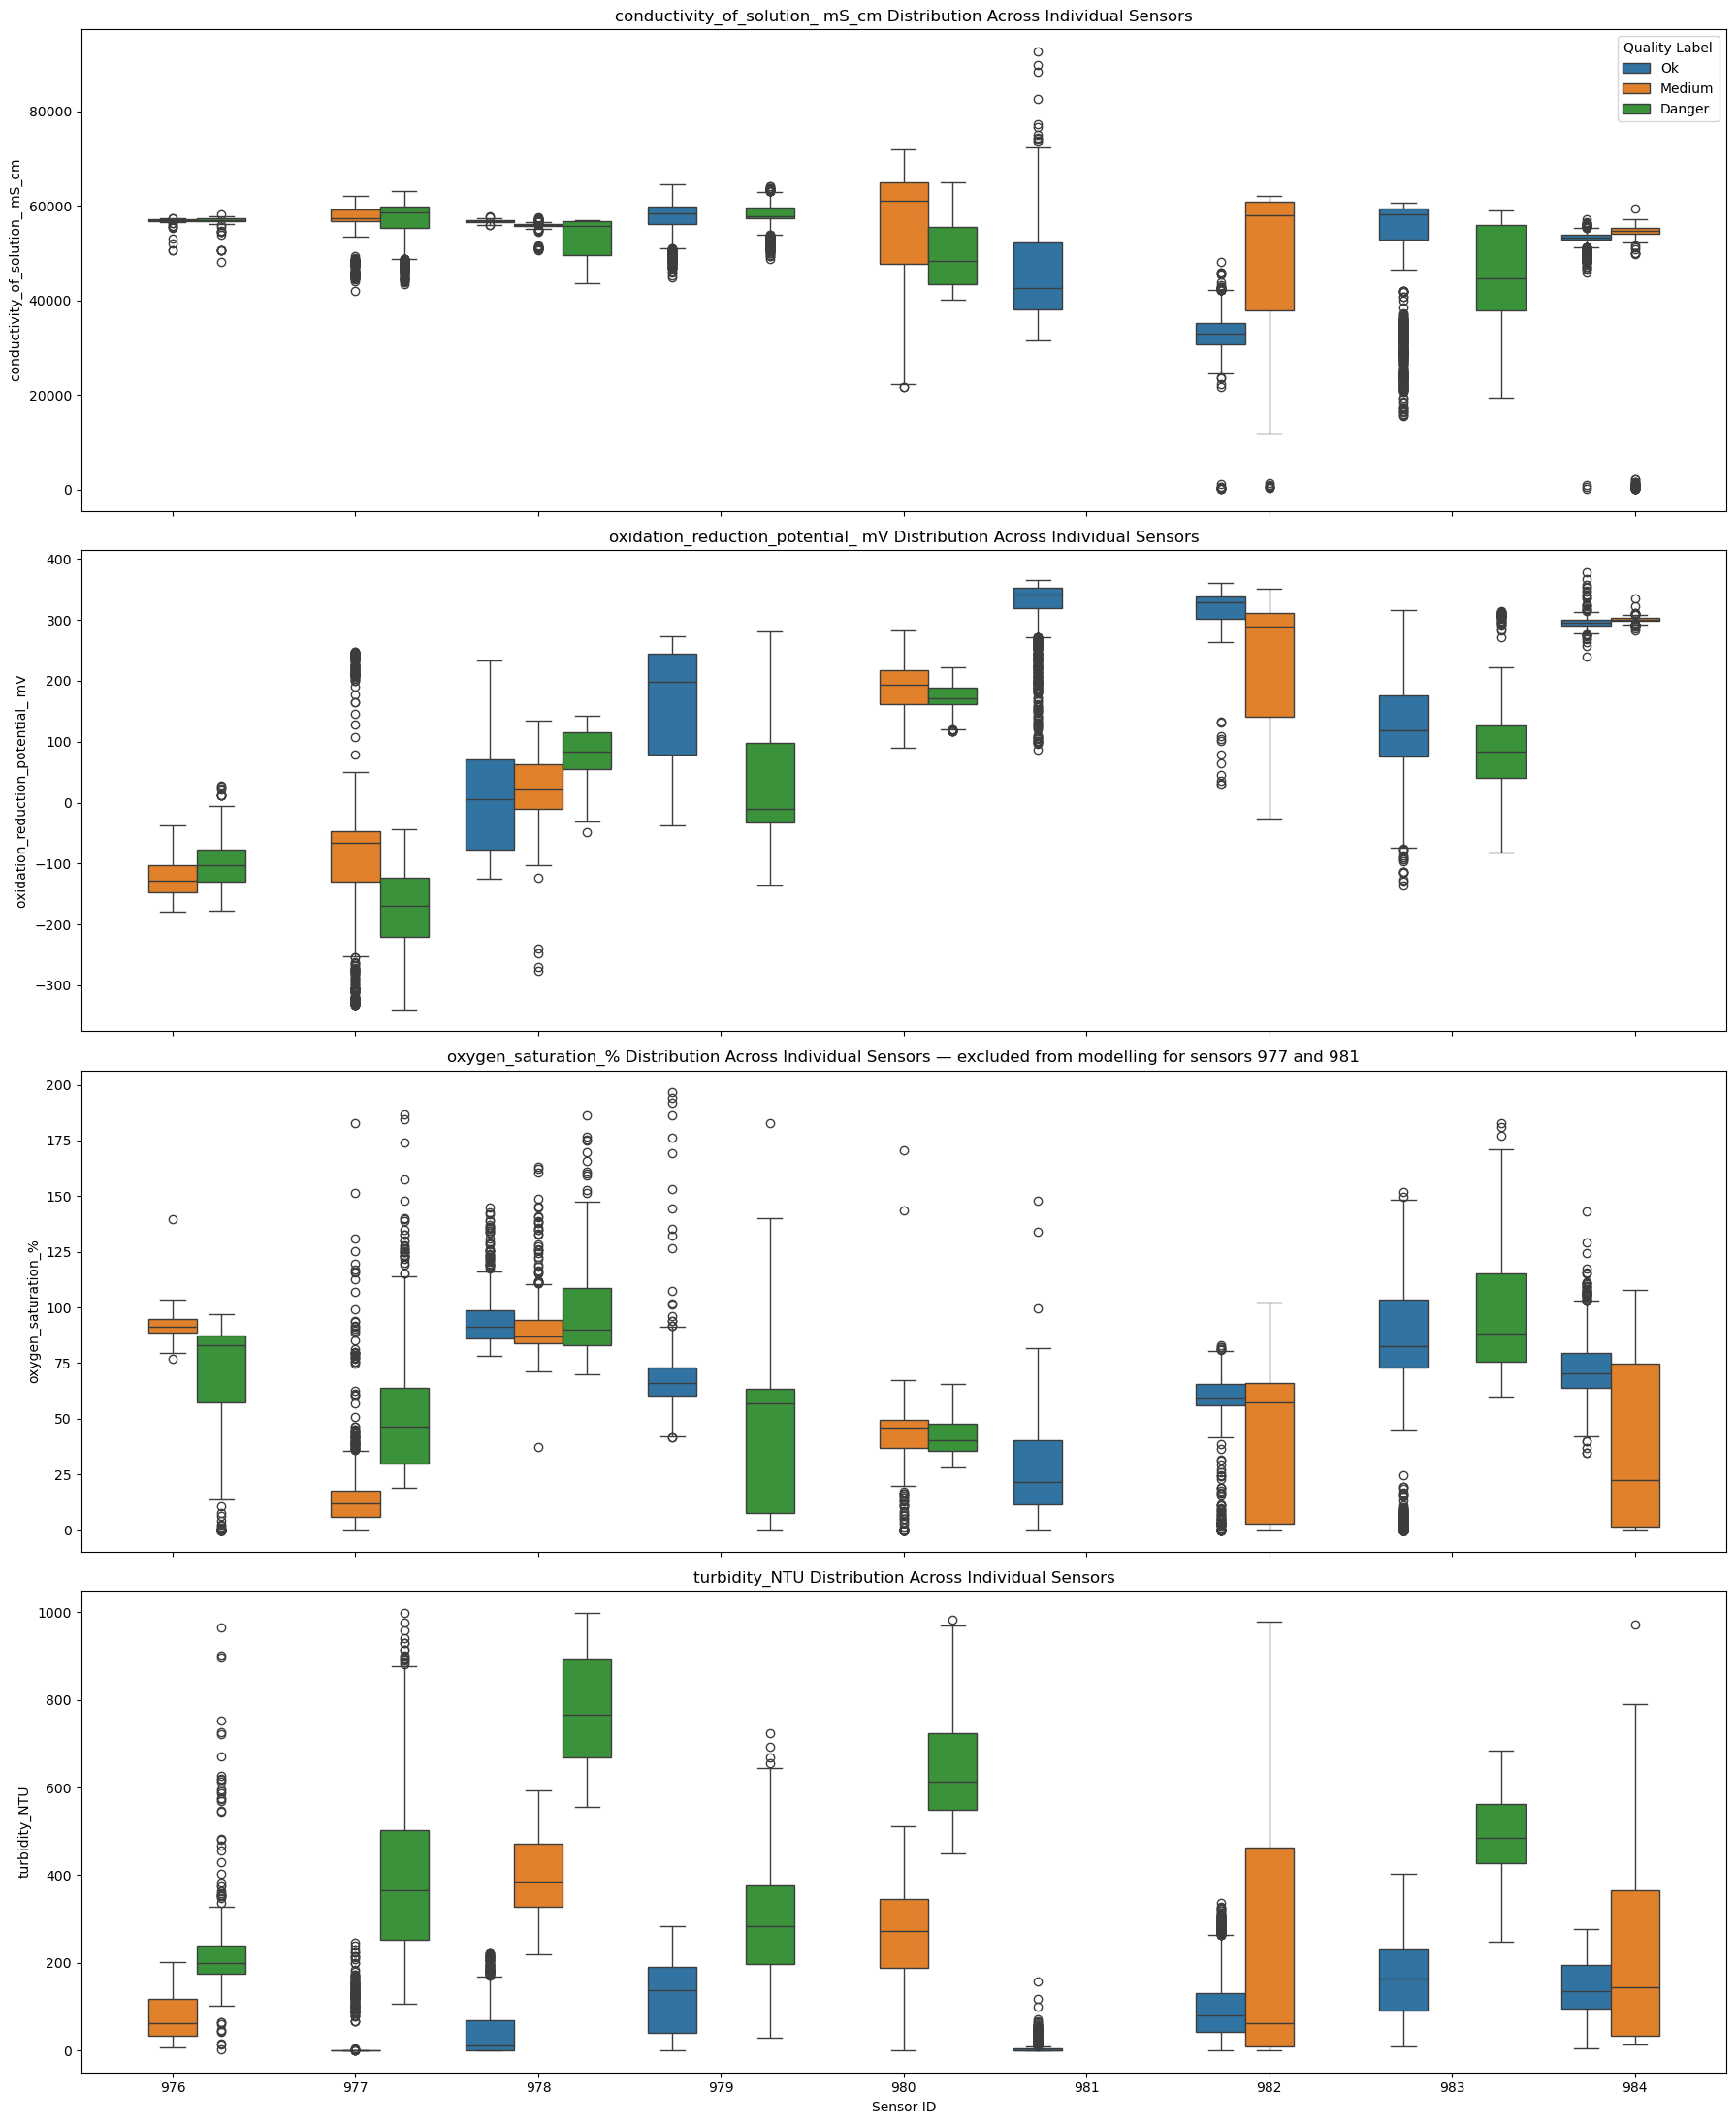

In [13]:
fig, axes = plt.subplots(
    nrows=len(all_features),
    ncols=1,
    figsize=(18, 22),
    sharex=True,
)

for position, (axis, feature) in enumerate(
    zip(axes, all_features)
):
    sns.boxplot(
        data=final_training_df,
        x=sensor_id_col,
        y=feature,
        hue="Water_Quality_Label",
        hue_order=label_order,
        ax=axis,
    )

    title = f"{feature} Distribution Across Individual Sensors"

    if feature == oxygen_col:
        title += " — excluded from modelling for sensors 977 and 981"

    axis.set_title(title)
    axis.set_ylabel(feature)

    if position < len(all_features) - 1:
        axis.set_xlabel("")

    if position == 0:
        axis.legend(
            title="Quality Label",
            loc="upper right",
        )
    elif axis.get_legend() is not None:
        axis.get_legend().remove()

axes[-1].set_xlabel("Sensor ID")

plt.tight_layout()
plt.show()


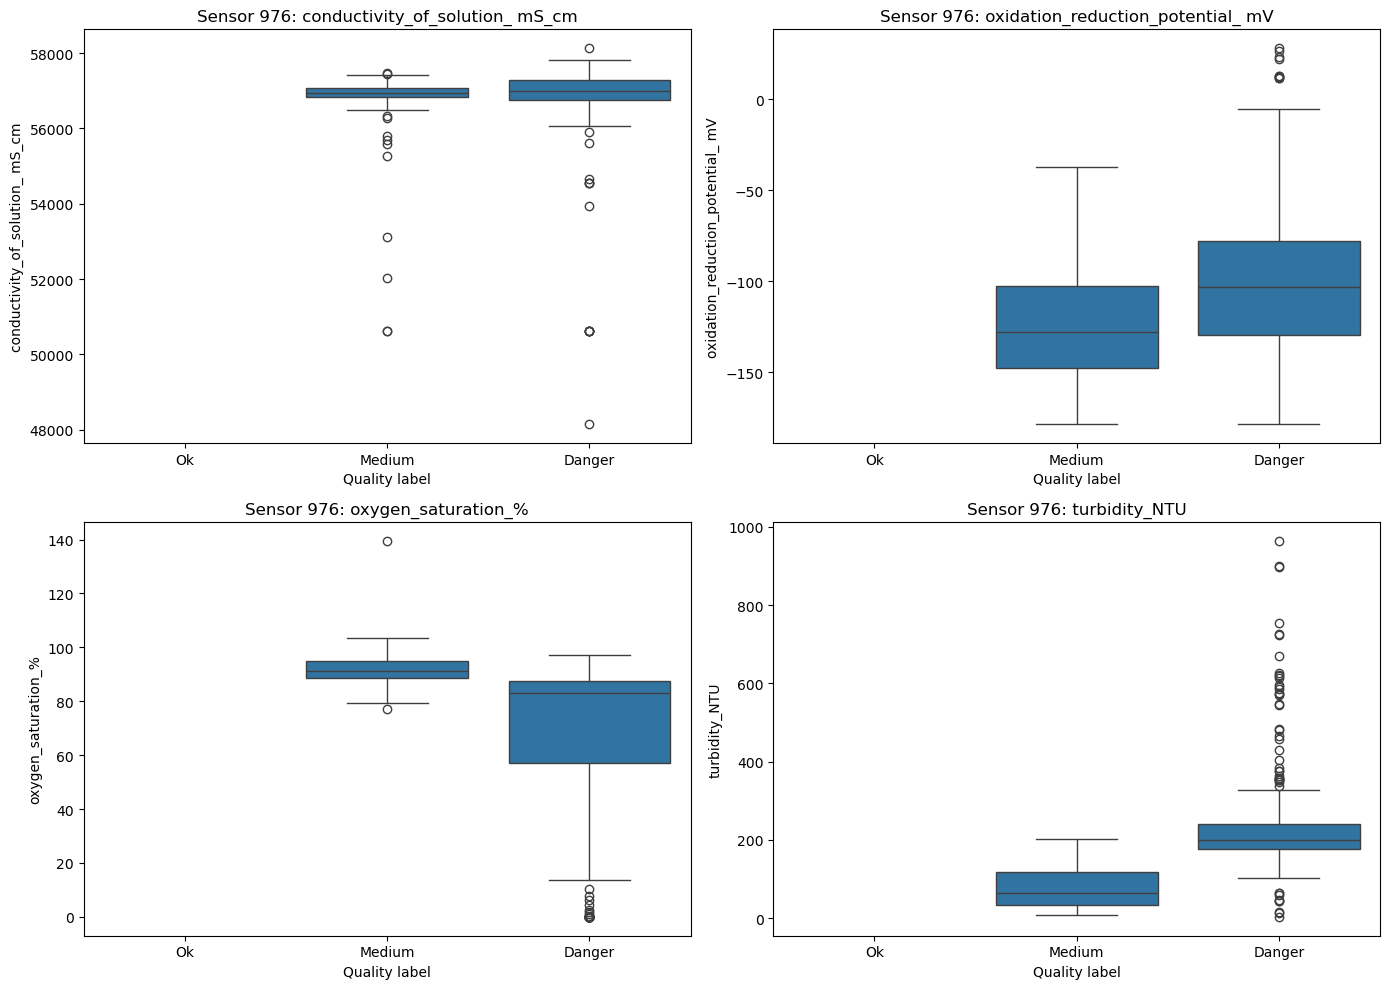

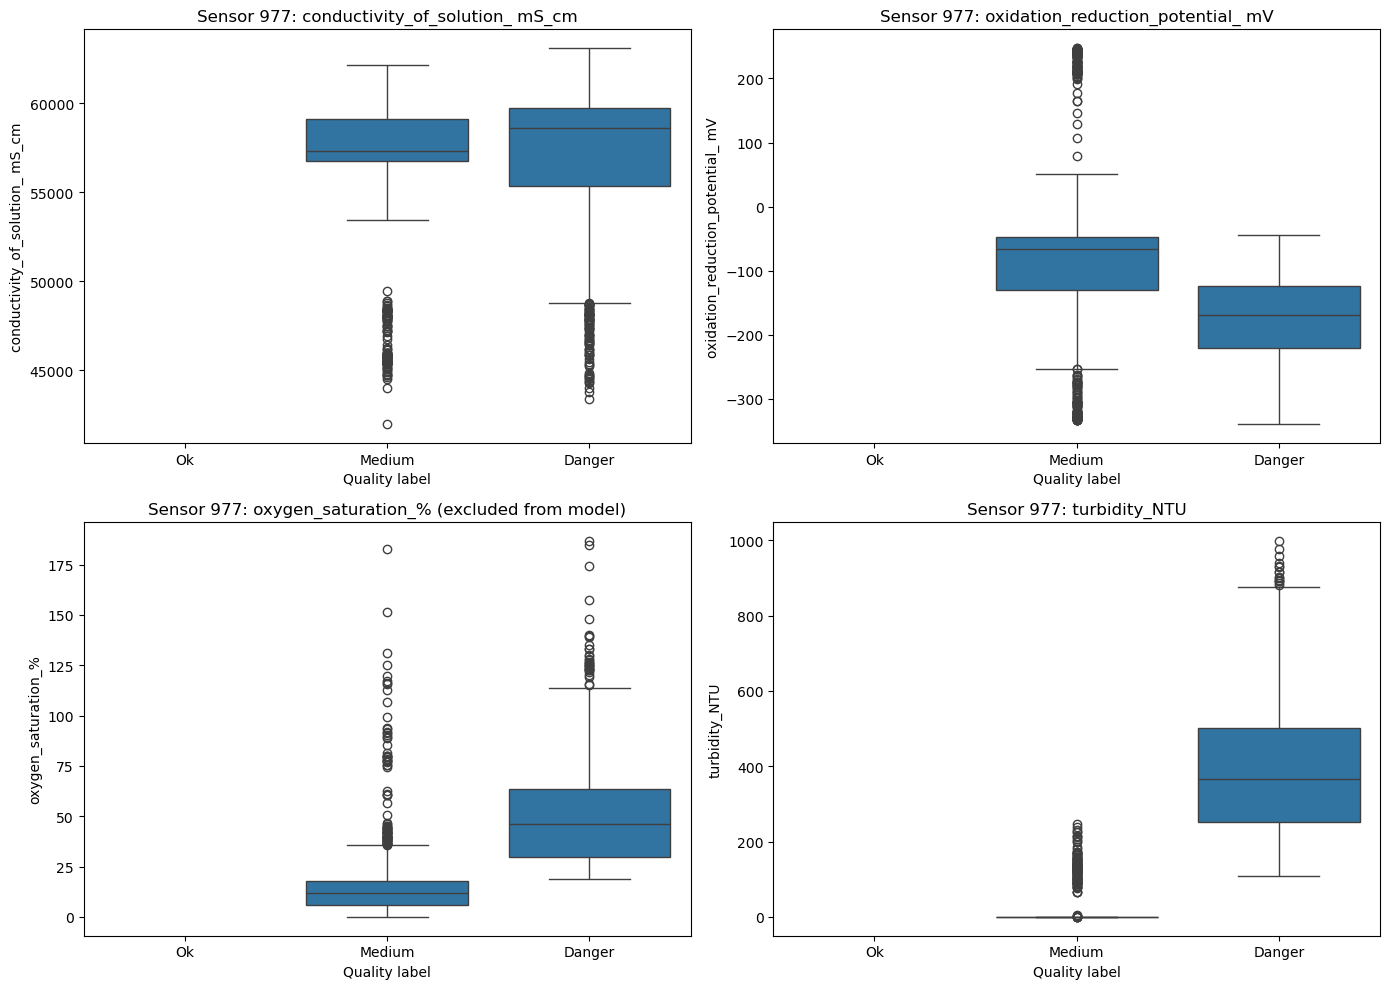

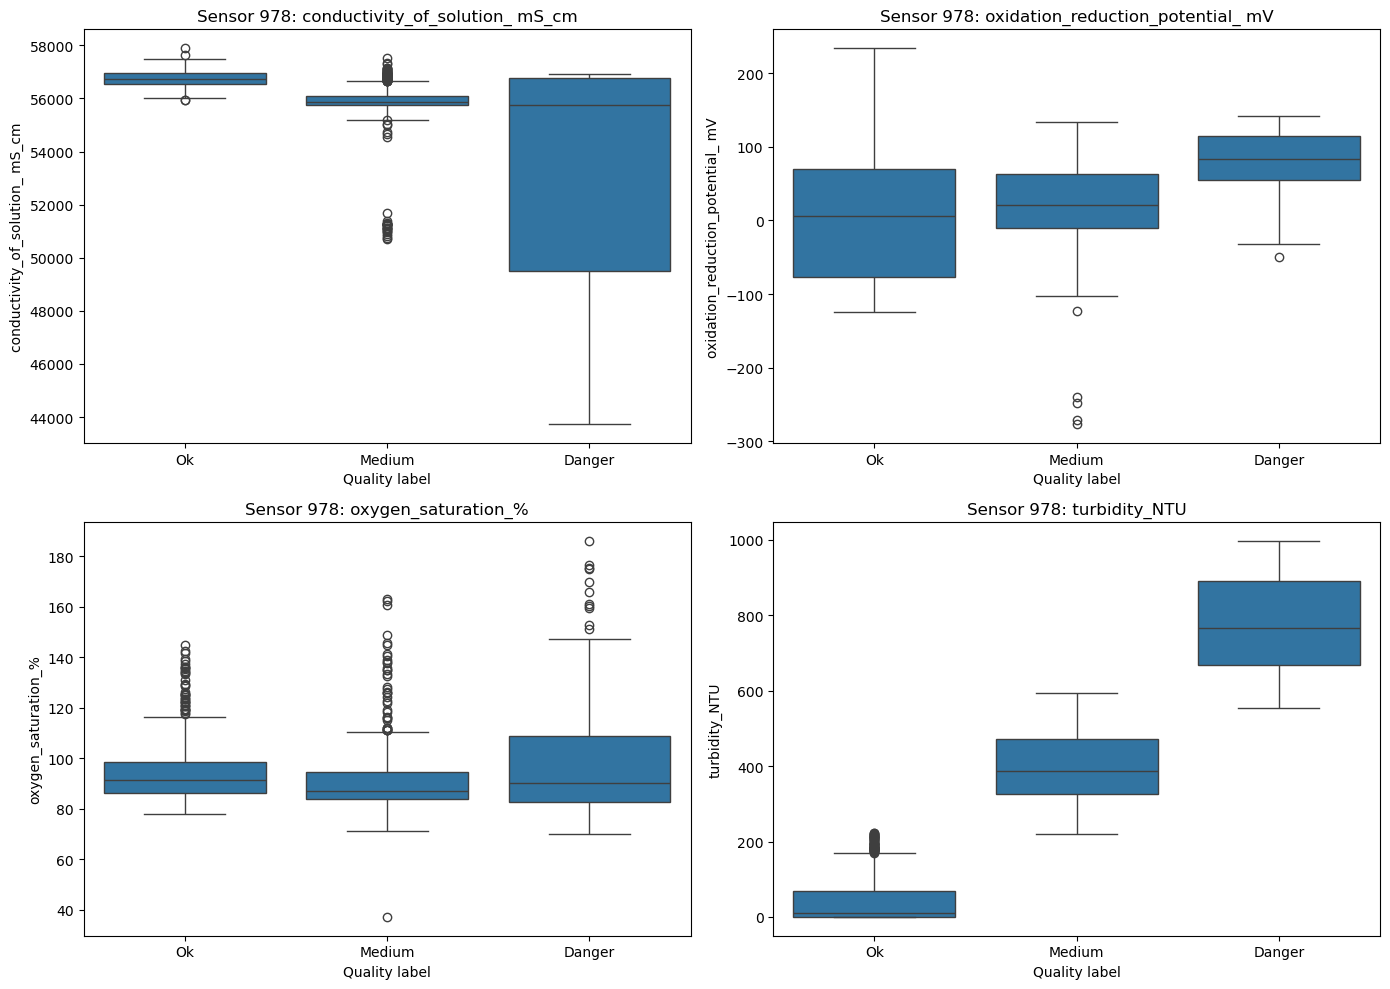

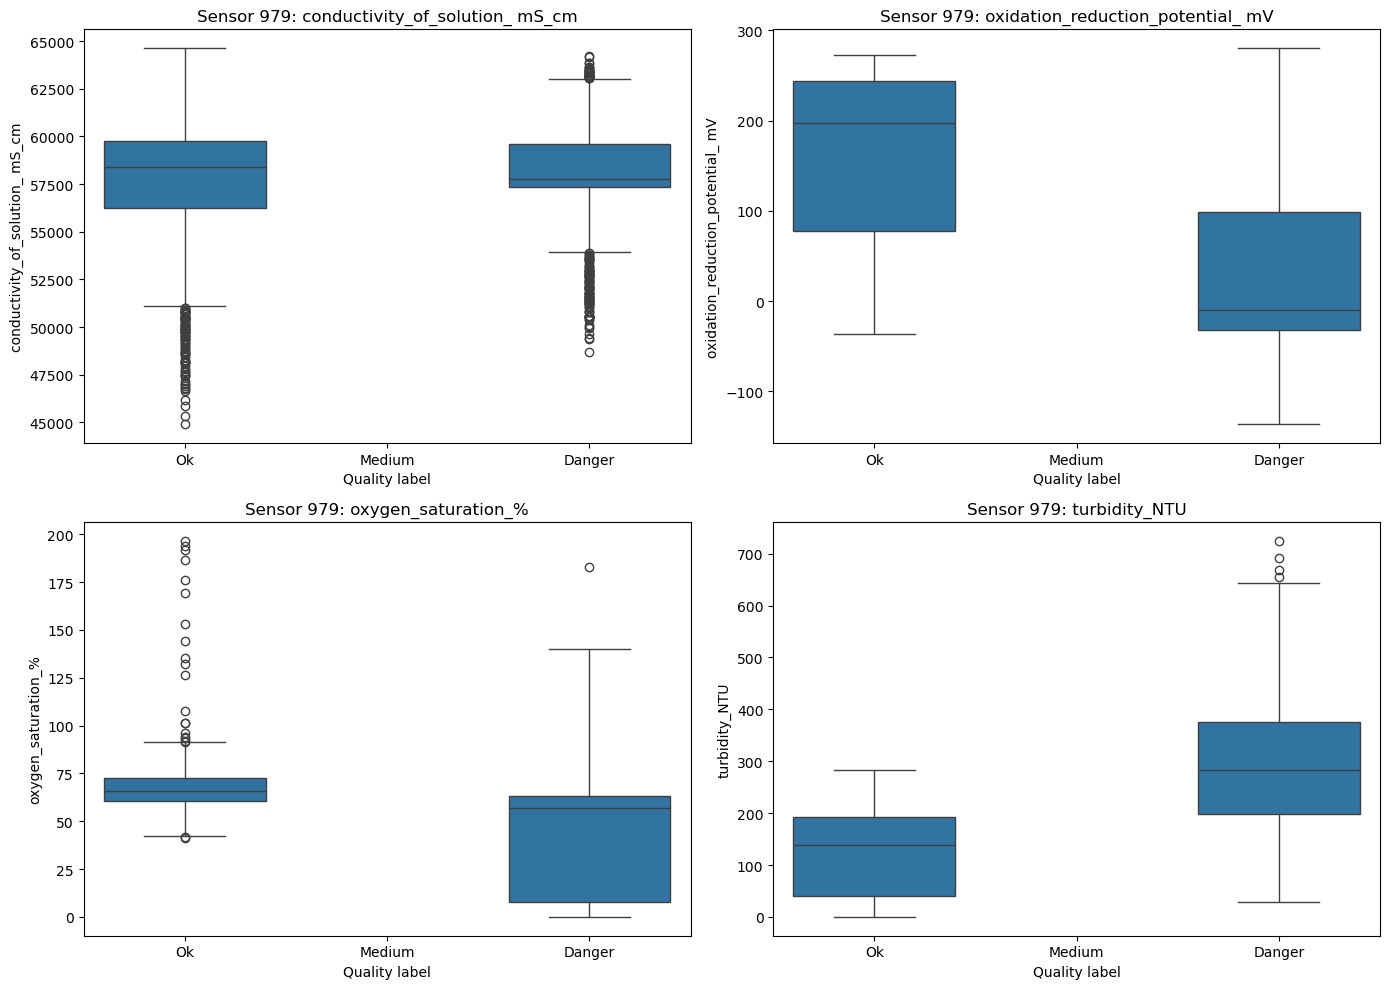

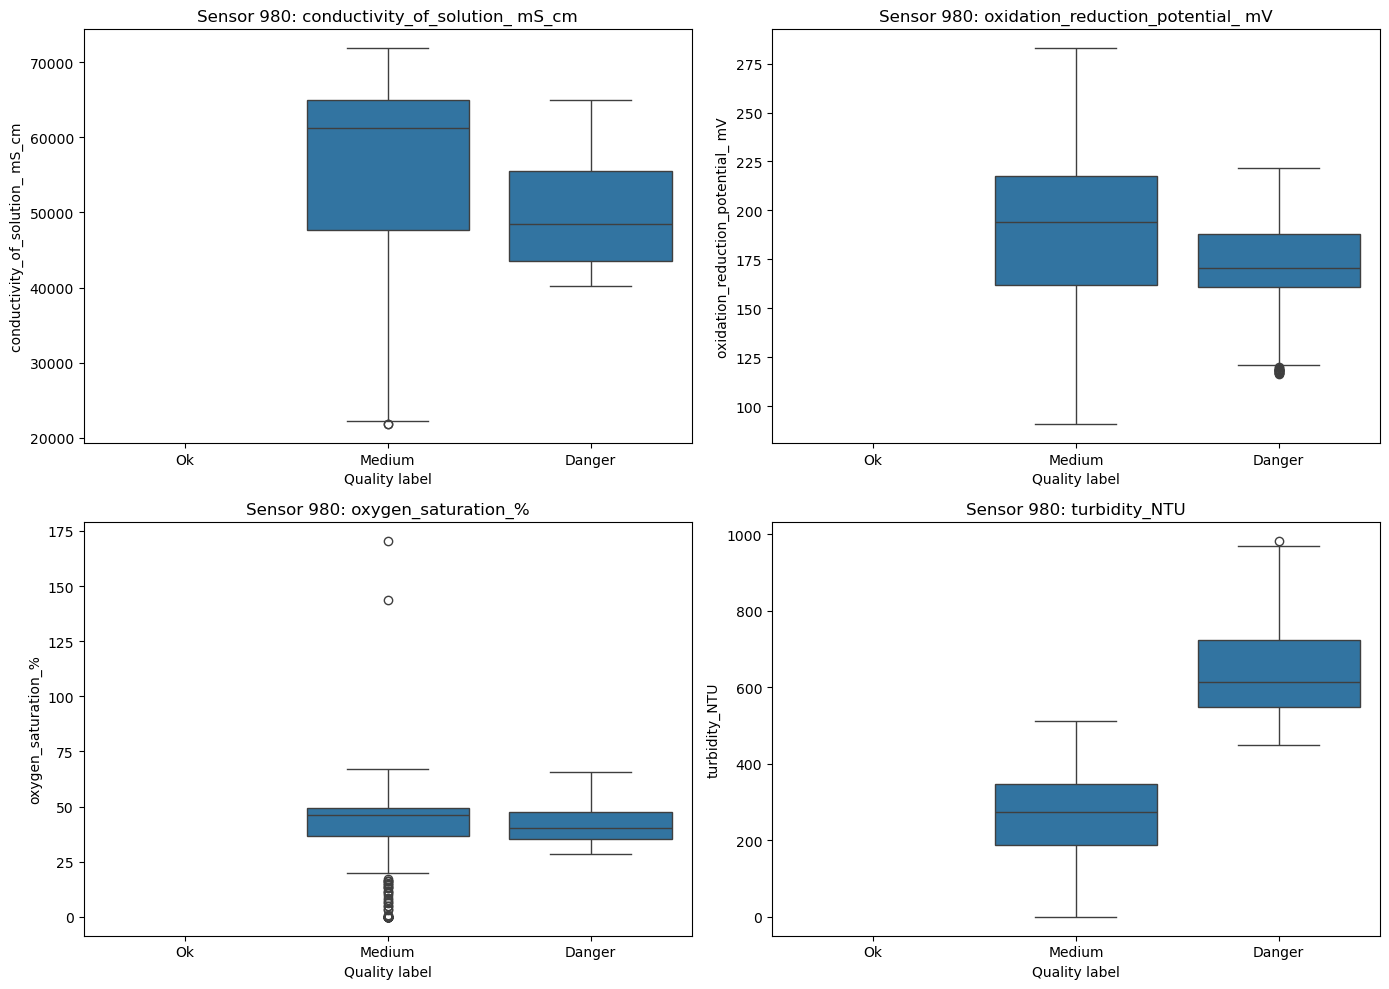

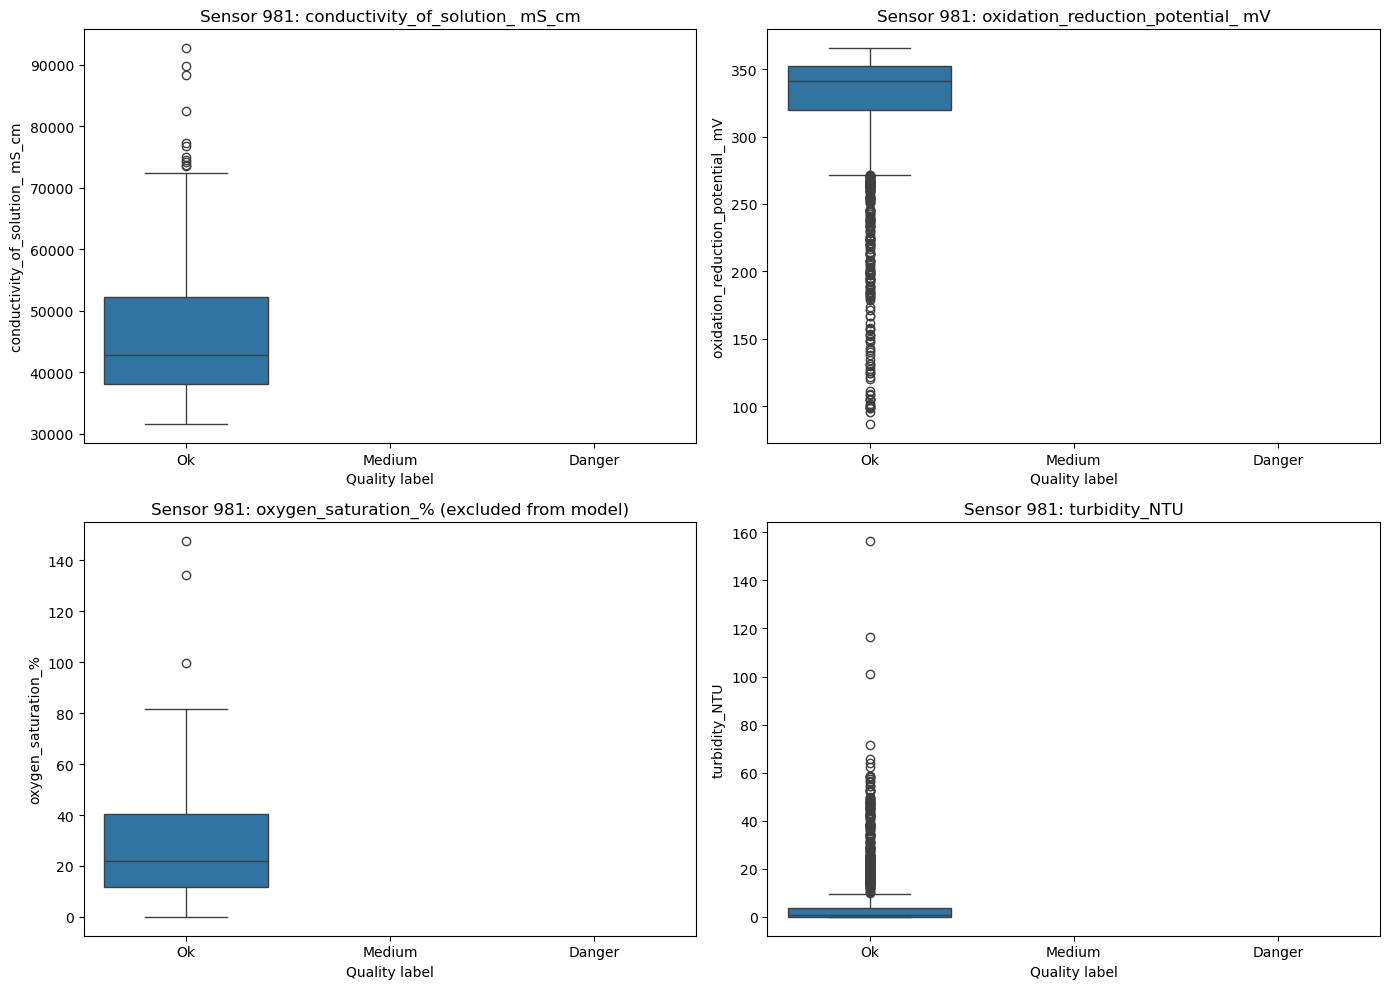

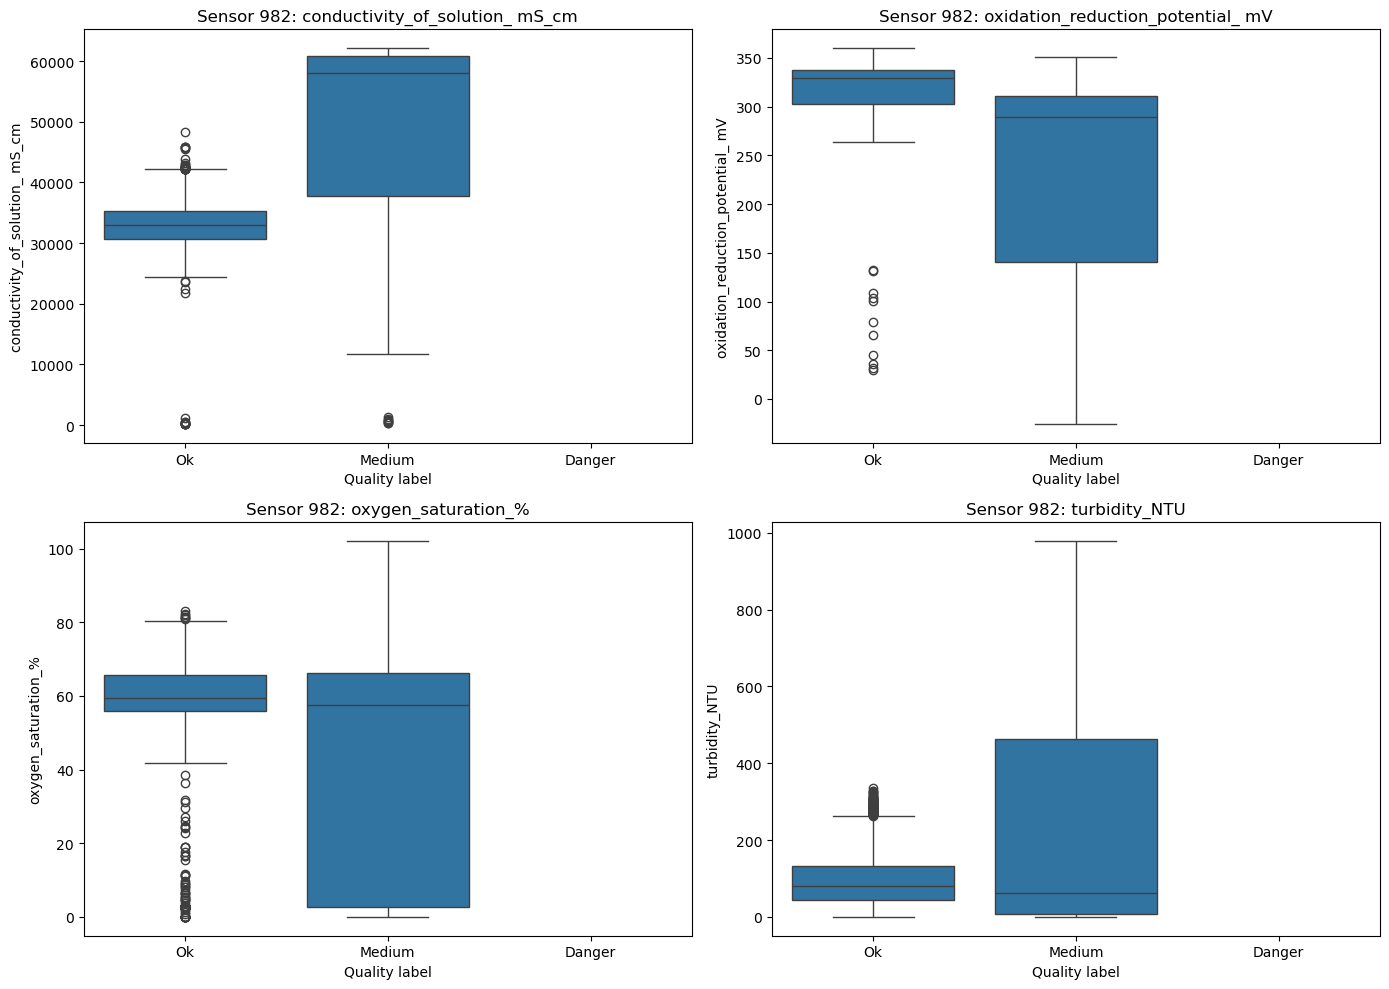

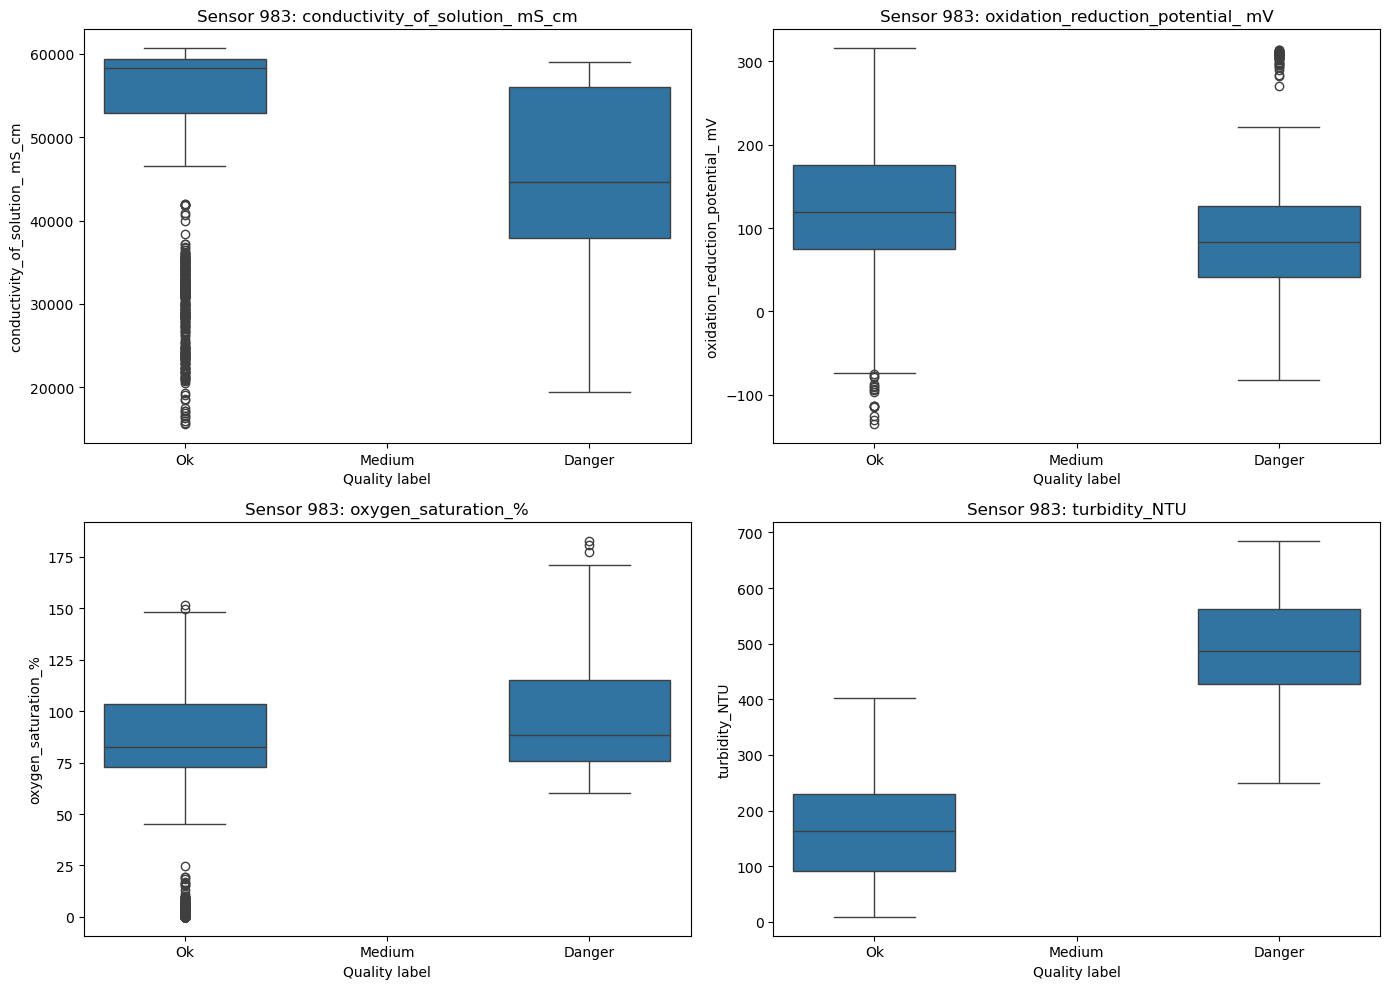

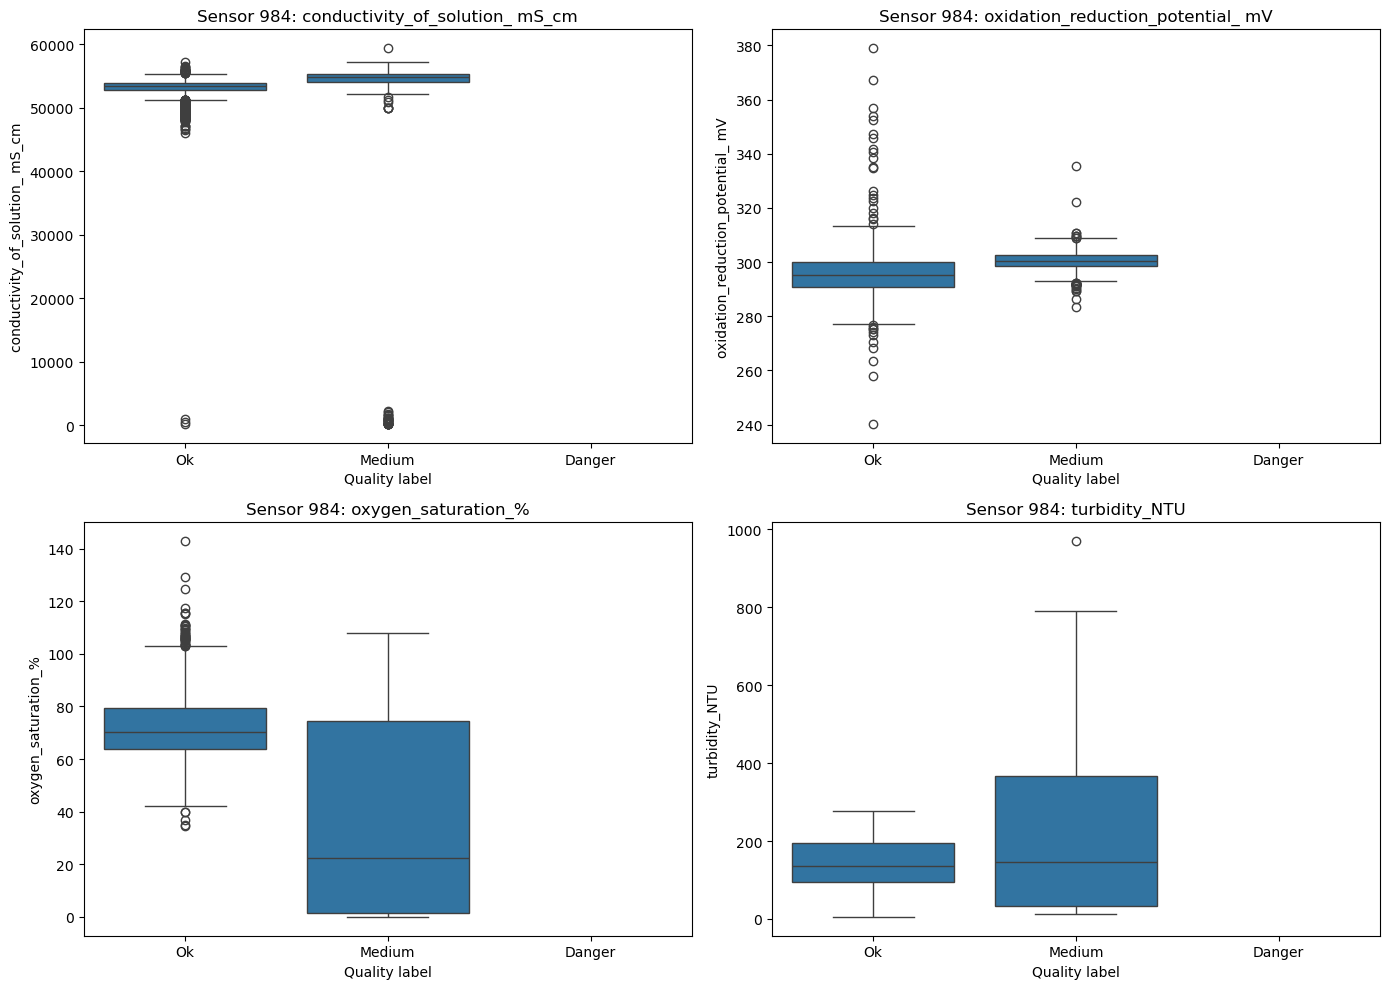

In [14]:
for sensor, sensor_data in final_training_df.groupby(
    sensor_id_col,
    sort=False,
):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(14, 10),
    )

    axes = axes.flatten()

    for axis, feature in zip(axes, all_features):
        sns.boxplot(
            data=sensor_data,
            x="Water_Quality_Label",
            y=feature,
            order=label_order,
            ax=axis,
        )

        title = f"Sensor {sensor}: {feature}"

        if (
            feature == oxygen_col
            and sensor in OXYGEN_EXCLUDED_SENSORS
        ):
            title += " (excluded from model)"

        axis.set_title(title)
        axis.set_xlabel("Quality label")

    plt.tight_layout()
    plt.show()


## 10. Contribution audit

The oxygen contribution is zero for sensors 977 and 981.


In [15]:
cluster_contributions = clustered_df[
    [
        sensor_id_col,
        "cluster",
        "_row_id",
        "oxygen_used_in_model",
    ]
].copy()

cluster_contributions = cluster_contributions.set_index(
    "_row_id"
)

cluster_contributions[contribution_columns] = (
    label_scaled_df.loc[
        cluster_contributions.index,
        contribution_columns,
    ]
)

cluster_contributions = (
    cluster_contributions
    .groupby([sensor_id_col, "cluster"])
    .agg(
        **{
            column: (column, "median")
            for column in contribution_columns
        },
        oxygen_used_in_model=(
            "oxygen_used_in_model",
            "first",
        ),
    )
    .reset_index()
)

cluster_contributions = cluster_contributions.merge(
    cluster_quality[
        [
            sensor_id_col,
            "cluster",
            "cluster_quality_score",
            "Water_Quality_Label",
            "model_features",
        ]
    ],
    on=[sensor_id_col, "cluster"],
    how="left",
)

display(
    cluster_contributions.sort_values(
        [sensor_id_col, "cluster_quality_score"]
    )
)


,sensor_id,cluster,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,oxygen_used_in_model,cluster_quality_score,Water_Quality_Label,model_features
0,976,0,-0.740542,1.905249,-0.616455,0.341659,True,0.164910,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
1,976,1,0.188250,1.763023,-0.406570,0.719585,True,0.444455,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
2,976,2,2.946682,1.683998,-0.568694,0.455351,True,0.771929,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
4,977,1,-1.179341,1.503801,0.000000,0.409202,False,0.171125,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
3,977,0,0.920405,2.219481,0.000000,0.464585,False,0.737672,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
5,977,2,3.039258,2.048719,0.000000,1.015788,False,1.343078,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
8,978,2,-1.100059,1.027849,-0.621736,0.322142,True,-0.048728,Ok,"conductivity_of_solution_ mS_cm, oxidation_red..."
7,978,1,1.511294,0.925890,-0.514453,0.606935,True,0.430848,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
6,978,0,4.147566,0.522574,-0.594615,0.726050,True,0.975852,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
11,979,2,-0.214944,-0.227999,-0.011400,0.761578,True,0.052960,Ok,"conductivity_of_solution_ mS_cm, oxidation_red..."


## 11. Optional inspection helper


SENSOR 981
Observations: 1631
Silhouette score: 0.5561

Label distribution:


,observations,percentage
Water_Quality_Label,,
Ok,1631,100.0



Cluster summary:


,cluster,Water_Quality_Label,observations,cluster_quality_score,conductivity_of_solution_ mS_cm_mean,conductivity_of_solution_ mS_cm_median,oxidation_reduction_potential_ mV_mean,oxidation_reduction_potential_ mV_median,oxygen_saturation_%_mean,oxygen_saturation_%_median,turbidity_NTU_mean,turbidity_NTU_median
1,1,Ok,794,-0.410,39363.696,38017.465,349.374,352.810,25.648,22.60,3.410,1.200
2,2,Ok,271,-0.321,41734.188,41524.460,227.062,245.240,10.097,10.28,0.212,0.000
0,0,Ok,566,-0.252,56492.262,55341.705,329.923,331.855,38.505,49.22,11.744,1.645



Statistics by quality label:


conductivity_of_solution_ mS_cm                       \
                                              count       mean    median   
Water_Quality_Label                                                        
Ok                                             1631  45701.631  42706.97   

                                                   \
                          std       min       max   
Water_Quality_Label                                 
Ok                   8991.863  31479.01  92692.07   

                    oxidation_reduction_potential_ mV                   \
                                                count     mean  median   
Water_Quality_Label                                                      
Ok                                               1631  322.301  341.52   

                             ... oxygen_saturation_%                       \
                        std  ...              median     std  min     max   
Water_Quality_Label          ...                                            
Ok                   49.917  ...               21.78  18.775  0.0  147.79   

                    turbidity_NTU                                     
                            count   mean median     std  min     max  
Water_Quality_Label                                                   
Ok                           1631  5.771   0.65  12.473  0.0  156.52  

[1 rows x 24 columns]


Cluster score contributions:


,sensor_id,cluster,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,oxygen_used_in_model,cluster_quality_score,Water_Quality_Label,model_features
16,981,1,-1.171,-1.245,0.0,0.341,False,-0.410,Ok,"conductivity_of_solution_ mS_cm, oxidation_red..."
17,981,2,-1.179,-0.540,0.0,0.108,False,-0.321,Ok,"conductivity_of_solution_ mS_cm, oxidation_red..."
15,981,0,-1.168,-1.107,0.0,0.898,False,-0.252,Ok,"conductivity_of_solution_ mS_cm, oxidation_red..."


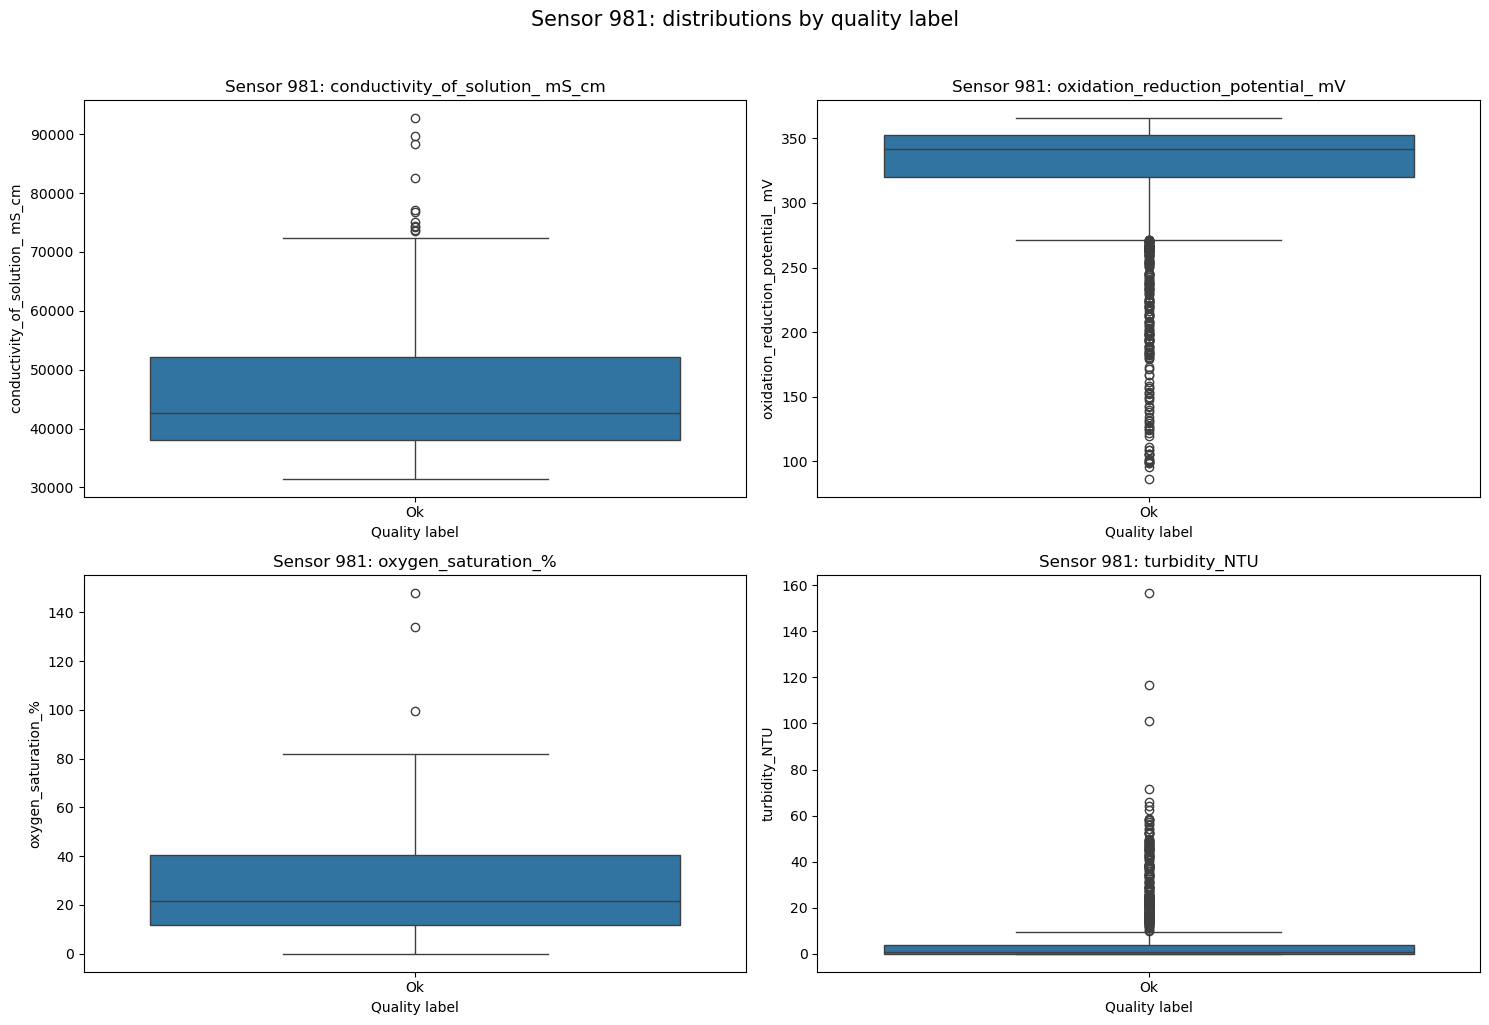

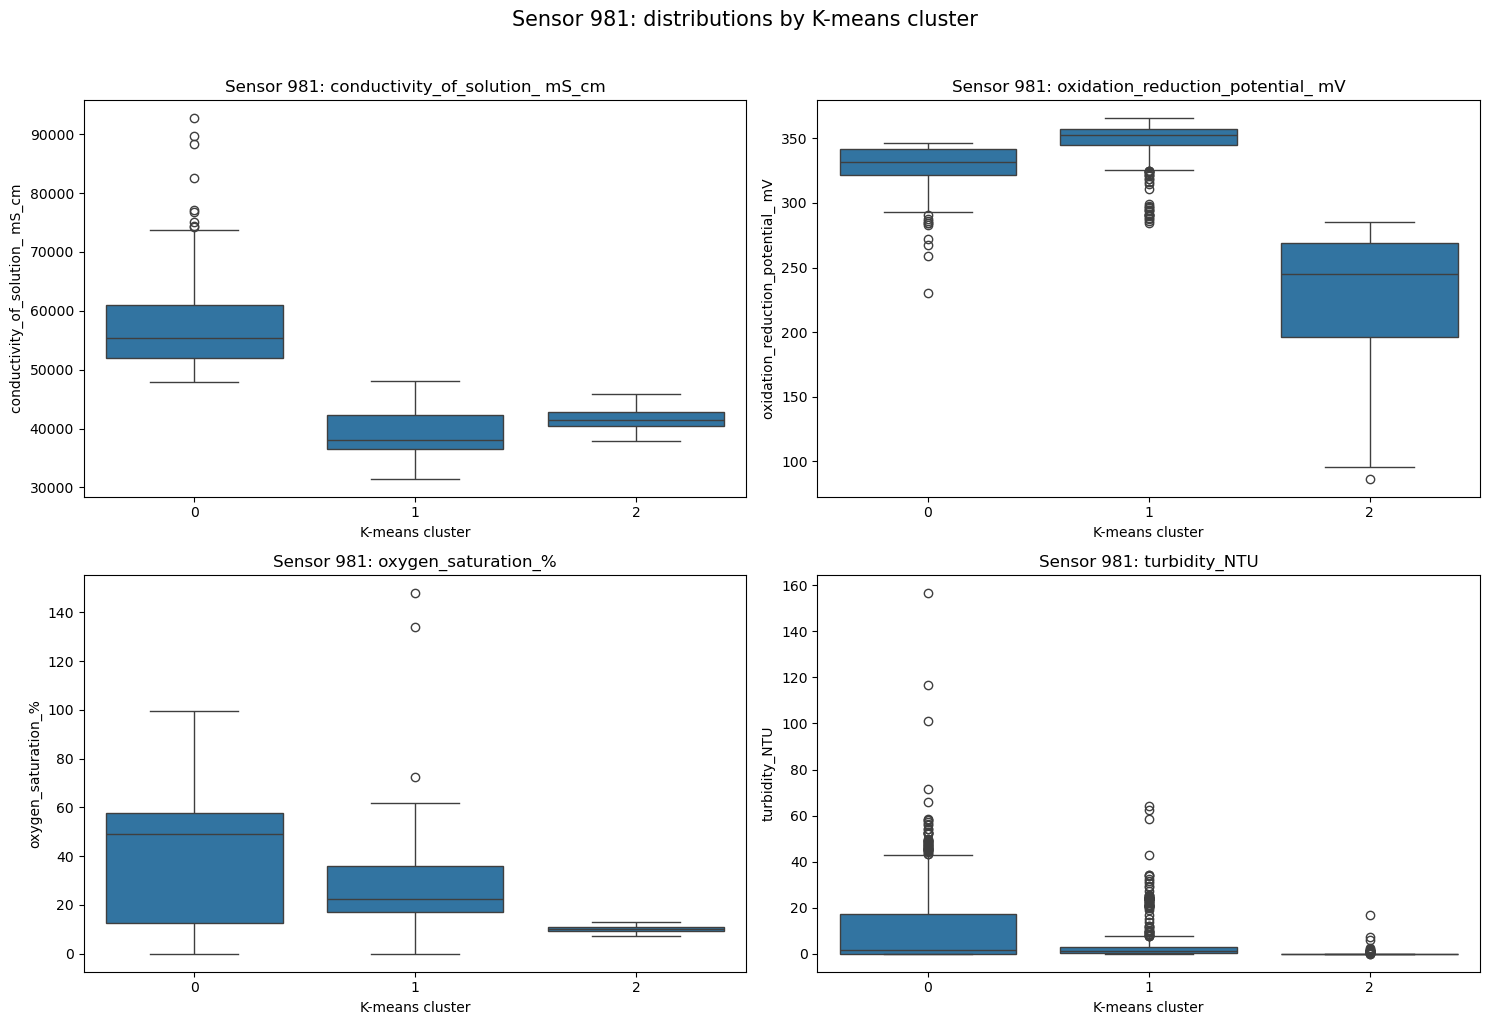

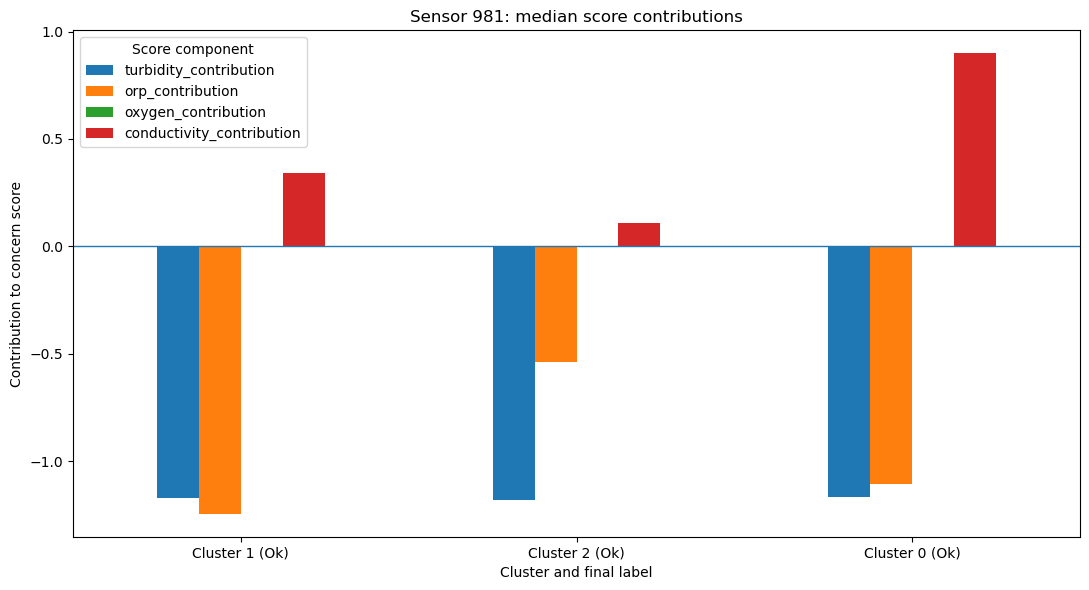

In [16]:
SENSOR_TO_INSPECT = 981

if inspect_sensors is not None:
    inspection = inspect_sensors(
        SENSOR_TO_INSPECT,
        final_training_df,
        cluster_contributions=cluster_contributions,
        silhouette_df=silhouette_df,
    )
else:
    print(
        "inspect_sensors was not loaded. "
        "The clustering results above are still available."
    )


## 12. Optional dashboard-ready latest statuses

For sensors 977 and 981, the returned status uses conductivity, ORP, and turbidity only. The raw oxygen value may still be displayed, but the output includes an explicit warning that oxygen was excluded.


In [17]:
if build_latest_sensor_statuses is not None:
    latest_sensor_statuses = build_latest_sensor_statuses(
        final_training_df,
        cluster_contributions,
        timestamp_col=timestamp_col,
    )

    latest_sensor_statuses["oxygen_used_in_model"] = (
        ~latest_sensor_statuses[sensor_id_col].isin(
            OXYGEN_EXCLUDED_SENSORS
        )
    )

    latest_sensor_statuses["model_note"] = np.where(
        latest_sensor_statuses["oxygen_used_in_model"],
        "Conductivity, ORP, oxygen and turbidity used",
        (
            "Oxygen excluded due to suspected sensor drift; "
            "status uses conductivity, ORP and turbidity"
        ),
    )

    display(latest_sensor_statuses)
else:
    latest_sensor_statuses = None
    print(
        "build_latest_sensor_statuses was not loaded. "
        "Skip the remaining website-output cells."
    )


,sensor_id,date_insert,Water_Quality_Label,status_rank,cluster,cluster_quality_score,main_driver,explanation,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,oxygen_used_in_model,model_note
0,976,2025-11-05 09:00:00,Danger,2,2,0.771929,Turbidity,High concern is mainly associated with elevate...,58135.10,28.13,0.00,901.18,2.946682,1.683998,-0.568694,0.455351,True,"Conductivity, ORP, oxygen and turbidity used"
1,977,2026-01-19 08:00:00,Medium,1,1,0.171125,ORP,Moderate concern is mainly associated with low...,48309.35,226.69,0.00,0.00,-1.179341,1.503801,0.000000,0.409202,False,Oxygen excluded due to suspected sensor drift;...
2,978,2025-12-25 03:00:00,Medium,1,1,0.430848,Turbidity,Moderate concern is mainly associated with ele...,55823.70,9.61,37.11,435.74,1.511294,0.925890,-0.514453,0.606935,True,"Conductivity, ORP, oxygen and turbidity used"
3,979,2026-04-11 09:00:00,Danger,2,0,0.493721,Turbidity,High concern is mainly associated with elevate...,64206.19,-39.64,0.77,577.06,1.523684,0.318459,0.128763,0.908266,True,"Conductivity, ORP, oxygen and turbidity used"
4,980,2025-12-12 17:00:00,Medium,1,0,0.197983,Conductivity,Moderate concern is mainly associated with con...,66961.40,207.18,0.00,297.02,0.372638,-0.297785,0.399490,0.572259,True,"Conductivity, ORP, oxygen and turbidity used"
5,981,2025-10-03 03:00:00,Ok,0,0,-0.251725,Turbidity,"Overall concern is low, mainly because of low ...",53765.01,340.49,0.00,0.00,-1.167891,-1.107431,0.000000,0.898287,False,Oxygen excluded due to suspected sensor drift;...
6,982,2026-01-26 02:00:00,Medium,1,2,0.201490,Conductivity,Moderate concern is mainly associated with con...,61393.21,150.61,2.79,55.81,-1.053214,-0.766136,0.239526,3.015710,True,"Conductivity, ORP, oxygen and turbidity used"
7,983,2026-04-16 06:00:00,Ok,0,1,0.102010,Oxygen saturation,"Overall concern is low, mainly because of good...",57002.71,67.51,0.00,31.55,0.057356,0.346504,-0.362769,0.202033,True,"Conductivity, ORP, oxygen and turbidity used"
8,984,2026-01-08 11:00:00,Medium,1,1,0.179892,Oxygen saturation,Moderate concern is mainly associated with low...,56056.12,301.04,1.71,138.56,-0.905266,-0.898237,1.502318,1.283319,True,"Conductivity, ORP, oxygen and turbidity used"


In [18]:
if latest_sensor_statuses is not None:
    website_cards = latest_sensor_statuses[
        [
            sensor_id_col,
            timestamp_col,
            "Water_Quality_Label",
            "main_driver",
            "explanation",
            "cluster_quality_score",
            "oxygen_used_in_model",
            "model_note",
            turbidity_col,
            orp_col,
            oxygen_col,
            conductivity_col,
        ]
    ]

    display(website_cards)


,sensor_id,date_insert,Water_Quality_Label,main_driver,explanation,cluster_quality_score,oxygen_used_in_model,model_note,turbidity_NTU,oxidation_reduction_potential_ mV,oxygen_saturation_%,conductivity_of_solution_ mS_cm
0,976,2025-11-05 09:00:00,Danger,Turbidity,High concern is mainly associated with elevate...,0.771929,True,"Conductivity, ORP, oxygen and turbidity used",901.18,28.13,0.00,58135.10
1,977,2026-01-19 08:00:00,Medium,ORP,Moderate concern is mainly associated with low...,0.171125,False,Oxygen excluded due to suspected sensor drift;...,0.00,226.69,0.00,48309.35
2,978,2025-12-25 03:00:00,Medium,Turbidity,Moderate concern is mainly associated with ele...,0.430848,True,"Conductivity, ORP, oxygen and turbidity used",435.74,9.61,37.11,55823.70
3,979,2026-04-11 09:00:00,Danger,Turbidity,High concern is mainly associated with elevate...,0.493721,True,"Conductivity, ORP, oxygen and turbidity used",577.06,-39.64,0.77,64206.19
4,980,2025-12-12 17:00:00,Medium,Conductivity,Moderate concern is mainly associated with con...,0.197983,True,"Conductivity, ORP, oxygen and turbidity used",297.02,207.18,0.00,66961.40
5,981,2025-10-03 03:00:00,Ok,Turbidity,"Overall concern is low, mainly because of low ...",-0.251725,False,Oxygen excluded due to suspected sensor drift;...,0.00,340.49,0.00,53765.01
6,982,2026-01-26 02:00:00,Medium,Conductivity,Moderate concern is mainly associated with con...,0.201490,True,"Conductivity, ORP, oxygen and turbidity used",55.81,150.61,2.79,61393.21
7,983,2026-04-16 06:00:00,Ok,Oxygen saturation,"Overall concern is low, mainly because of good...",0.102010,True,"Conductivity, ORP, oxygen and turbidity used",31.55,67.51,0.00,57002.71
8,984,2026-01-08 11:00:00,Medium,Oxygen saturation,Moderate concern is mainly associated with low...,0.179892,True,"Conductivity, ORP, oxygen and turbidity used",138.56,301.04,1.71,56056.12


In [19]:
if latest_sensor_statuses is not None:
    website_records = (
        website_cards
        .replace({np.nan: None})
        .to_dict(orient="records")
    )

    website_records
